<div style="background:linear-gradient(135deg,#0b0f1a 0%,#0d1b2a 50%,#0b1520 100%);border:1px solid #1e3a5f;border-radius:16px;padding:40px 48px;font-family:'Georgia',serif;">

<div style="display:flex;align-items:center;gap:16px;margin-bottom:8px;">
  <span style="font-size:2.8rem;">🔭</span>
  <div>
    <h1 style="margin:0;font-size:2rem;font-weight:700;letter-spacing:0.08em;color:#e8f4fd;font-family:'Courier New',monospace;">COSMICA</h1>
    <p style="margin:0;font-size:0.9rem;color:#5b9bd5;letter-spacing:0.2em;text-transform:uppercase;font-family:'Courier New',monospace;">YOLOv11s · Astronomical Object Detection</p>
  </div>
</div>

<hr style="border:none;border-top:1px solid #1e3a5f;margin:24px 0;"/>

<table style="width:100%;border-collapse:collapse;font-family:'Courier New',monospace;font-size:0.82rem;">
<thead>
<tr style="background:#0d1f33;">
  <th style="padding:10px 16px;text-align:left;color:#5b9bd5;letter-spacing:0.1em;border-bottom:1px solid #1e3a5f;">CELL</th>
  <th style="padding:10px 16px;text-align:left;color:#5b9bd5;letter-spacing:0.1em;border-bottom:1px solid #1e3a5f;">TASK</th>
  <th style="padding:10px 16px;text-align:left;color:#5b9bd5;letter-spacing:0.1em;border-bottom:1px solid #1e3a5f;">TIME</th>
</tr>
</thead>
<tbody>
<tr style="border-bottom:1px solid #132030;"><td style="padding:9px 16px;color:#a8c8e8;">01</td><td style="padding:9px 16px;color:#c8dff0;">Environment fix + Install</td><td style="padding:9px 16px;color:#7aab6e;">~3 min</td></tr>
<tr style="border-bottom:1px solid #132030;background:#0a1a28;"><td style="padding:9px 16px;color:#a8c8e8;">02</td><td style="padding:9px 16px;color:#c8dff0;">Inspect dataset</td><td style="padding:9px 16px;color:#7aab6e;">30 sec</td></tr>
<tr style="border-bottom:1px solid #132030;"><td style="padding:9px 16px;color:#a8c8e8;">03</td><td style="padding:9px 16px;color:#c8dff0;">Prepare dataset</td><td style="padding:9px 16px;color:#7aab6e;">~2 min</td></tr>
<tr style="border-bottom:1px solid #132030;background:#0a1a28;"><td style="padding:9px 16px;color:#a8c8e8;">04</td><td style="padding:9px 16px;color:#c8dff0;">Train YOLOv11s</td><td style="padding:9px 16px;color:#e8a94a;">~3 hrs</td></tr>
<tr style="border-bottom:1px solid #132030;"><td style="padding:9px 16px;color:#a8c8e8;">05</td><td style="padding:9px 16px;color:#c8dff0;">Evaluate on test set</td><td style="padding:9px 16px;color:#7aab6e;">~5 min</td></tr>
<tr style="border-bottom:1px solid #132030;background:#0a1a28;"><td style="padding:9px 16px;color:#a8c8e8;">06</td><td style="padding:9px 16px;color:#c8dff0;">Visual detection samples</td><td style="padding:9px 16px;color:#7aab6e;">~2 min</td></tr>
<tr style="border-bottom:1px solid #132030;"><td style="padding:9px 16px;color:#a8c8e8;">07</td><td style="padding:9px 16px;color:#c8dff0;">Test your telescope image</td><td style="padding:9px 16px;color:#7aab6e;">~2 min</td></tr>
<tr><td style="padding:9px 16px;color:#a8c8e8;background:#0a1a28;">08</td><td style="padding:9px 16px;color:#c8dff0;background:#0a1a28;">Save & list outputs</td><td style="padding:9px 16px;color:#7aab6e;background:#0a1a28;">~1 min</td></tr>
</tbody>
</table>

<hr style="border:none;border-top:1px solid #1e3a5f;margin:24px 0;"/>

<div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;font-family:'Courier New',monospace;font-size:0.8rem;">
  <div style="background:#0a1a28;border:1px solid #1e3a5f;border-radius:8px;padding:14px 16px;">
    <div style="color:#5b9bd5;letter-spacing:0.12em;margin-bottom:8px;">▸ BEFORE RUNNING</div>
    <div style="color:#a8c8e8;">① Session options → Accelerator → <strong style="color:#e8f4fd;">GPU T4×2</strong></div>
    <div style="color:#a8c8e8;margin-top:4px;">② Attach dataset via <strong style="color:#e8f4fd;">+ Add Data</strong></div>
    <div style="color:#6a8fa8;font-size:0.75rem;margin-top:6px;">search: astronomical-object-detection</div>
  </div>
  <div style="background:#0a1a28;border:1px solid #1e3a5f;border-radius:8px;padding:14px 16px;">
    <div style="color:#5b9bd5;letter-spacing:0.12em;margin-bottom:8px;">▸ CLASSES</div>
    <div style="color:#ef9f27;">● comet</div>
    <div style="color:#e5593a;">● galaxy</div>
    <div style="color:#1d9e75;">● globular_cluster</div>
    <div style="color:#8b5cf6;">● nebula</div>
  </div>
</div>

</div>

In [1]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 01 · Environment Fix + Install                                    ║
# ║  Run this cell once. It will restart the kernel automatically.          ║
# ║  After restart, run ALL remaining cells normally (Run All).             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import subprocess, sys

def pip(*args):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + list(args), check=False)

# ── 1. Swap torch to cu118 (supports P100 sm_60 through A100 sm_90) ───────
TORCH_CANDIDATES = [
    ('2.2.0+cu118', '0.17.0+cu118'),
    ('2.2.1+cu118', '0.17.1+cu118'),
    ('2.3.0+cu118', '0.18.0+cu118'),
    ('2.4.0+cu118', '0.19.0+cu118'),
]
for tv, tvv in TORCH_CANDIDATES:
    print(f'▸ Trying torch=={tv} ...')
    r = subprocess.run([
        sys.executable, '-m', 'pip', 'install', '-q', '--upgrade',
        f'torch=={tv}', f'torchvision=={tvv}',
        '--index-url', 'https://download.pytorch.org/whl/cu118'
    ])
    if r.returncode == 0:
        print(f'  ✅ torch=={tv}')
        break
    print('  ✗ not found, trying next ...')

# ── 2. Install ultralytics ─────────────────────────────────────────────────
print('▸ Installing Ultralytics ...')
pip('ultralytics')

# ── 3. Pin Pillow and NumPy AFTER ultralytics (it likes to drag them up) ──
# ultralytics pulls numpy back to 2.x — we re-pin here to keep it at 1.x
# which is required by torch 2.2 compiled C extensions on this image.
print('▸ Re-pinning Pillow<12 and NumPy<2 (after ultralytics) ...')
pip('pillow>=10,<12', 'numpy>=1.26,<2.0')

# ── 4. Restart kernel — new packages become active, Kaggle auto-continues ─
print('\n✅ Done — restarting kernel (Kaggle will continue from Cell 02) ...')
import IPython
IPython.get_ipython().kernel.do_shutdown(restart=True)


▸ Trying torch==2.2.0+cu118 ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.6/811.6 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 80.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 51.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 102.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 18.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 15.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 MB 2.4 MB/s eta 0:00:00

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.2.0+cu118 which is incompatible.


  ✅ torch==2.2.0+cu118
▸ Installing Ultralytics ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.7 MB/s eta 0:00:00
▸ Re-pinning Pillow<12 and NumPy<2 (after ultralytics) ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 89.3 MB/s eta 0:00:00

✅ Done — restarting kernel (Kaggle will continue from Cell 02) ...


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you 

{'status': 'ok', 'restart': True}

In [1]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 02 · Imports + Paths + GPU Check                                  ║
# ║  Runs AFTER the kernel restart triggered by Cell 01.                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import os, shutil, glob, yaml, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import Counter
from ultralytics import YOLO
import torch

# ── Paths ──────────────────────────────────────────────────────────────────
# Auto-detect dataset mount point (slug may differ from source ID)
INPUT_BASE  = '/kaggle/input'
WORK_DIR    = '/kaggle/working'
CLASS_NAMES = ['comet', 'galaxy', 'globular_cluster', 'nebula']

# Find the dataset directory (handles any slug: cosmica, astronomical-object-detection, etc.)
INPUT_DIR = None
_candidates = [
    'astronomical-object-detection',
    'cosmica',
    'cosmica-dataset',
]
for _c in _candidates:
    _p = os.path.join(INPUT_BASE, _c)
    if os.path.exists(_p):
        INPUT_DIR = _p
        break

# Fallback: grab the first directory under /kaggle/input
if INPUT_DIR is None:
    _all = [d for d in os.listdir(INPUT_BASE)
            if os.path.isdir(os.path.join(INPUT_BASE, d))]
    if _all:
        INPUT_DIR = os.path.join(INPUT_BASE, _all[0])
        print(f'  ⚠  Using first available dataset: {INPUT_DIR}')

if INPUT_DIR is None:
    print('  ❌ No dataset found under /kaggle/input/')
    print('     + Add Data → search "astronomical-object-detection" → Add')
else:
    print(f'  ✅ Dataset : {INPUT_DIR}')

# ── GPU check ─────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    gpu  = torch.cuda.get_device_name(0)
    cap  = torch.cuda.get_device_capability(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  GPU    : {gpu}')
    print(f'  SM cap : sm_{cap[0]}{cap[1]}  ({"✅ supported" if cap[0] >= 6 else "❌ too old"})')
    print(f'  VRAM   : {vram:.1f} GB')
else:
    print('  ❌ No GPU — Session options → Accelerator → GPU T4×2')

print(f'  PyTorch : {torch.__version__}')
print(f'  NumPy   : {np.__version__}')
print(f'  Output  : {WORK_DIR}')


  ⚠  Using first available dataset: /kaggle/input/datasets
  ✅ Dataset : /kaggle/input/datasets
  GPU    : Tesla P100-PCIE-16GB
  SM cap : sm_60  (✅ supported)
  VRAM   : 17.1 GB
  PyTorch : 2.2.0+cu118
  NumPy   : 1.26.4
  Output  : /kaggle/working


<div style="background:#0a1520;border-left:3px solid #5b9bd5;padding:10px 18px;border-radius:0 6px 6px 0;font-family:'Courier New',monospace;font-size:0.82rem;color:#7aabb8;">▸ CELL 02 — Inspect Dataset · finds YAML, counts images per split</div>

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 02 · Inspect Dataset                                              ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# Walk input to find dataset.yaml
yamls = glob.glob(f'{INPUT_DIR}/**/*.yaml', recursive=True)
print(f'YAML files found: {len(yamls)}')
for y in yamls:
    print(f'  {y}')

if yamls:
    with open(yamls[0]) as f:
        cfg = yaml.safe_load(f)
    print(f'\nDataset config:')
    for k, v in cfg.items():
        print(f'  {k}: {v}')
    CLASS_NAMES  = cfg.get('names', CLASS_NAMES)
    DATASET_ROOT = Path(yamls[0]).parent
else:
    # Fallback: probe common subfolder names
    for sub in ['yolov11_balanced', 'yolo', 'dataset', '']:
        candidate = Path(INPUT_DIR) / sub
        if (candidate / 'train' / 'images').exists():
            DATASET_ROOT = candidate
            break
    else:
        DATASET_ROOT = Path(INPUT_DIR)

print(f'\n  Root    : {DATASET_ROOT}')
print(f'  Classes : {CLASS_NAMES}')
print()

# Count images per split
for split in ['train', 'valid', 'val', 'test']:
    img_dir = DATASET_ROOT / split / 'images'
    lbl_dir = DATASET_ROOT / split / 'labels'
    if img_dir.exists():
        n_img = len(list(img_dir.glob('*')))
        n_lbl = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
        print(f'  {split:<8s}  {n_img:5d} images  {n_lbl:5d} labels')

YAML files found: 1
  /kaggle/input/datasets/piratinskii/astronomical-object-detection/yolov11_balanced/dataset.yaml

Dataset config:
  train: train/images
  val: valid/images
  test: test/images
  nc: 4
  names: ['comet', 'galaxy', 'globular_cluster', 'nebula']

  Root    : /kaggle/input/datasets/piratinskii/astronomical-object-detection/yolov11_balanced
  Classes : ['comet', 'galaxy', 'globular_cluster', 'nebula']

  train     15589 images  15589 labels
  valid      1950 images   1950 labels
  test       1948 images   1948 labels


<div style="background:#0a1520;border-left:3px solid #5b9bd5;padding:10px 18px;border-radius:0 6px 6px 0;font-family:'Courier New',monospace;font-size:0.82rem;color:#7aabb8;">▸ CELL 03 — Prepare Dataset · copies labels to /kaggle/working/, symlinks images (read-only is fine)</div>

In [3]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 03 · Prepare Dataset                                              ║
# ║  Kaggle input is read-only — labels are copied, images are symlinked.   ║
# ╚══════════════════════════════════════════════════════════════════════════╝

LOCAL_DS = Path('/kaggle/working/cosmica_yolo')

# Detect valid vs val
val_name = 'valid' if (DATASET_ROOT / 'valid' / 'images').exists() else 'val'
SPLITS   = [('train', 'train'), ('val', val_name), ('test', 'test')]

for local_split, src_split in SPLITS:
    src_img = DATASET_ROOT / src_split / 'images'
    src_lbl = DATASET_ROOT / src_split / 'labels'
    dst_lbl = LOCAL_DS / local_split / 'labels'
    dst_img = LOCAL_DS / local_split / 'images'

    if not src_img.exists():
        print(f'  {local_split:<6s} · skipped (not found in dataset)')
        continue

    # Copy labels → writable working dir
    if dst_lbl.exists():
        shutil.rmtree(str(dst_lbl))
    shutil.copytree(str(src_lbl), str(dst_lbl))

    # Symlink images from read-only input
    if dst_img.exists() or dst_img.is_symlink():
        if dst_img.is_symlink():
            os.unlink(str(dst_img))
        else:
            shutil.rmtree(str(dst_img))
    os.symlink(str(src_img), str(dst_img))

    n_lbl = len(list(dst_lbl.glob('*.txt')))
    n_img = len(list(src_img.glob('*')))
    print(f'  {local_split:<6s}  {n_img:5d} images  {n_lbl:5d} labels  ✓')

# Write data.yaml
YAML_PATH = '/kaggle/working/cosmica_data.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump({
        'path':  str(LOCAL_DS),
        'train': 'train/images',
        'val':   'val/images',
        'test':  'test/images',
        'nc':    len(CLASS_NAMES),
        'names': CLASS_NAMES
    }, f, default_flow_style=False)

print('\n  ✅ Dataset ready.')
print(f'  YAML: {YAML_PATH}')
print()
print(open(YAML_PATH).read())

  train   15589 images  15589 labels  ✓
  val      1950 images   1950 labels  ✓
  test     1948 images   1948 labels  ✓

  ✅ Dataset ready.
  YAML: /kaggle/working/cosmica_data.yaml

names:
- comet
- galaxy
- globular_cluster
- nebula
nc: 4
path: /kaggle/working/cosmica_yolo
test: test/images
train: train/images
val: val/images



<div style="background:#0a1520;border-left:3px solid #e8a94a;padding:10px 18px;border-radius:0 6px 6px 0;font-family:'Courier New',monospace;font-size:0.82rem;color:#c8a060;">▸ CELL 04 — Train YOLOv11s · ~3 hrs on T4 · runs can be monitored in the log output below</div>

In [4]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 04 · Train YOLOv11s                                               ║
# ║                                                                          ║
# ║  batch=16  → safe for both T4 (16 GB) and P100 (16 GB)                  ║
# ║  cache='disk' → uses Kaggle's fast NVMe SSD                             ║
# ║  50 epochs  → Kaggle gives 30 hrs/week, well within limit               ║
# ║  degrees=180 → full rotation for stars/galaxies (rotationally symmetric)║
# ╚══════════════════════════════════════════════════════════════════════════╝

model = YOLO('yolo11s.pt')

results = model.train(
    data          = YAML_PATH,
    epochs        = 50,
    imgsz         = 640,
    batch         = 16,          # safe for T4 and P100; raise to 32 if VRAM allows
    patience      = 20,
    device        = 0,
    cache         = 'disk',
    workers       = 4,
    amp           = True,

    project       = '/kaggle/working/runs',
    name          = 'cosmica_final',
    exist_ok      = True,

    optimizer     = 'AdamW',
    lr0           = 0.001,
    lrf           = 0.01,
    weight_decay  = 0.0005,
    momentum      = 0.937,
    warmup_epochs = 3,

    # Astronomy-tuned augmentations
    flipud  = 0.5,
    fliplr  = 0.5,
    degrees = 180,    # stars/galaxies have no preferred orientation
    hsv_h   = 0.01,
    hsv_s   = 0.3,
    hsv_v   = 0.4,
    scale   = 0.5,
    mosaic  = 1.0,

    pretrained = True,
    verbose    = True
)

print('\n  ✅ Training complete.')
d = results.results_dict
print(f'  mAP@50    : {d.get("metrics/mAP50(B)",    "?")}')
print(f'  mAP@50-95 : {d.get("metrics/mAP50-95(B)", "?")}')

Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.2.0+cu118 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cosmica_data.yaml, degrees=180, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cosmica_final, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=

<div style="background:#0a1520;border-left:3px solid #5b9bd5;padding:10px 18px;border-radius:0 6px 6px 0;font-family:'Courier New',monospace;font-size:0.82rem;color:#7aabb8;">▸ CELL 05 — Evaluate on test set</div>

In [5]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 05 · Evaluate on Test Set                                         ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# Locate best.pt (handles custom run names)
best_pt = '/kaggle/working/runs/cosmica_final/weights/best.pt'
if not os.path.exists(best_pt):
    candidates = sorted(
        glob.glob('/kaggle/working/runs/**/best.pt', recursive=True),
        key=os.path.getmtime, reverse=True
    )
    best_pt = candidates[0] if candidates else None

assert best_pt and os.path.exists(best_pt), (
    'best.pt not found — make sure Cell 04 completed successfully'
)
print(f'  Model : {best_pt}')
print(f'  Size  : {os.path.getsize(best_pt)/1e6:.1f} MB\n')

best_model = YOLO(best_pt)
metrics    = best_model.val(data=YAML_PATH, split='test')

print()
print('  ┌─────────────────────────────────────────┐')
print('  │          TEST SET RESULTS               │')
print('  ├─────────────────────────────────────────┤')
print(f'  │  mAP@50      {metrics.box.map50:.4f}  ({metrics.box.map50*100:.1f}%)              │')
print(f'  │  mAP@50-95   {metrics.box.map:.4f}                       │')
print(f'  │  Precision   {metrics.box.mp:.4f}                       │')
print(f'  │  Recall      {metrics.box.mr:.4f}                       │')
print('  ├─────────────────────────────────────────┤')
print('  │  Per-class mAP@50                       │')

for i, name in enumerate(CLASS_NAMES):
    try:
        v   = metrics.box.ap50[i]
        bar = '█' * int(v * 20)
        pad = ' ' * (20 - len(bar))
        print(f'  │  {name:<20s} {v:.3f}  {bar}{pad}  │')
    except Exception:
        pass
print('  └─────────────────────────────────────────┘')

  Model : /kaggle/working/runs/cosmica_final/weights/best.pt
  Size  : 19.2 MB

Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.2.0+cu118 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11s summary (fused): 101 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.9 ms, read: 9.5±4.4 MB/s, size: 60.0 KB)
val: Scanning /kaggle/input/datasets/piratinskii/astronomical-object-detection/yolov11_balanced/test/labels... 1948 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1948/1948 346.9it/s 5.6s0.1s
val: /kaggle/input/datasets/piratinskii/astronomical-object-detection/yolov11_balanced/test/images/orion_nebula1_jpg.rf.4887bdde492c1a76d201b4dd5a0d7dda.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/piratinskii/astronomical-object-detection/yolov11_balanced/test is not writable, cache not saved.
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 574, len(boxes) = 3635. To resolve this only boxes wi

<div style="background:#0a1520;border-left:3px solid #5b9bd5;padding:10px 18px;border-radius:0 6px 6px 0;font-family:'Courier New',monospace;font-size:0.82rem;color:#7aabb8;">▸ CELL 06 — Visual detection samples · renders 6 random test images with bounding boxes</div>

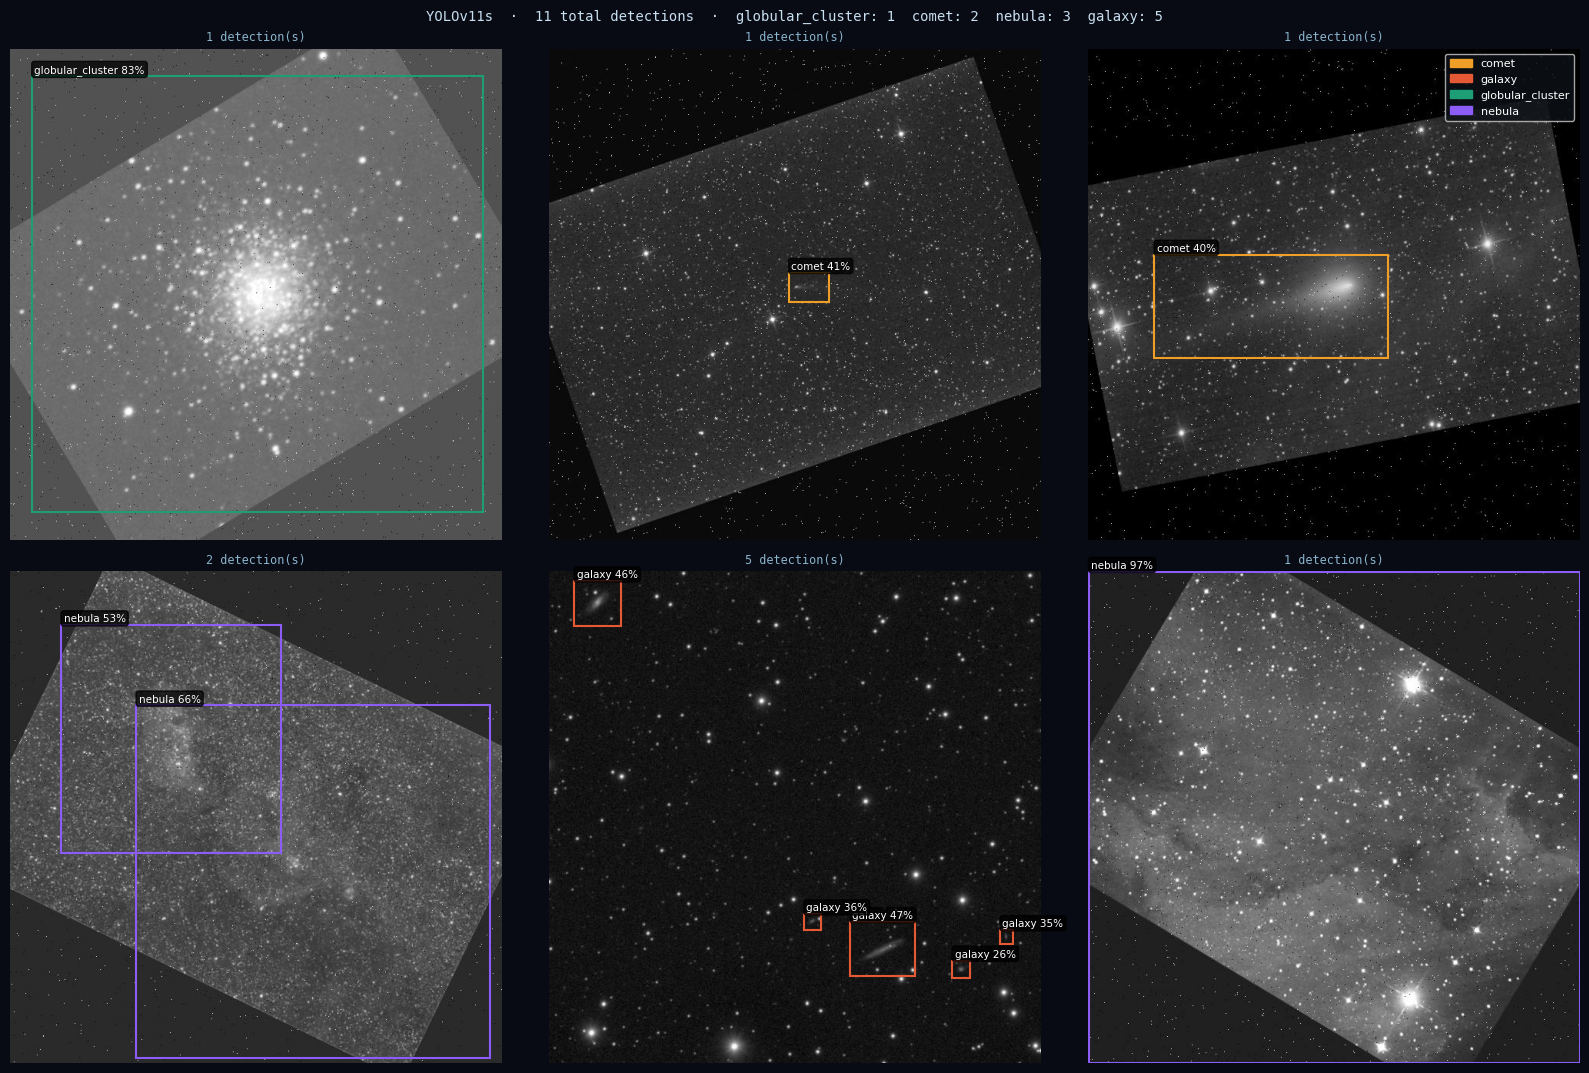

  Saved → /kaggle/working/sample_detections.png


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 06 · Visual Detection Samples                                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝

COLORS = {
    'comet':            (239/255, 159/255,  39/255),
    'galaxy':           (229/255,  89/255,  52/255),
    'globular_cluster': ( 29/255, 158/255, 117/255),
    'nebula':           (139/255,  92/255, 246/255),
}

test_imgs = glob.glob(str(LOCAL_DS / 'test' / 'images' / '*'))
if not test_imgs:
    test_imgs = glob.glob(str(LOCAL_DS / 'val' / 'images' / '*'))

sample = random.sample(test_imgs, min(6, len(test_imgs)))
preds  = best_model.predict(source=sample, conf=0.25, iou=0.45, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
fig.patch.set_facecolor('#080b14')
total  = 0
counts = Counter()

for ax, r in zip(axes.flat, preds):
    ax.imshow(r.orig_img[:, :, ::-1])
    ax.set_facecolor('#080b14')
    n = len(r.boxes) if r.boxes else 0
    total += n
    if r.boxes:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cid  = int(box.cls[0])
            conf = float(box.conf[0])
            name = CLASS_NAMES[cid] if cid < len(CLASS_NAMES) else str(cid)
            col  = COLORS.get(name, (1, 1, 1))
            counts[name] += 1
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=1.5, edgecolor=col, facecolor='none'
            ))
            ax.text(
                x1 + 3, y1 - 5, f'{name} {conf:.0%}',
                color='white', fontsize=7.5,
                bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.75)
            )
    ax.set_title(f'{n} detection(s)', color='#8ab4cc', fontsize=8.5,
                 fontfamily='monospace')
    ax.axis('off')

from matplotlib.patches import Patch
axes.flat[2].legend(
    handles=[Patch(color=v, label=k) for k, v in COLORS.items()],
    loc='upper right', facecolor='#0d1117', labelcolor='white', fontsize=8
)

title_str = (
    f'YOLOv11s  ·  {total} total detections  ·  '
    + '  '.join(f'{k}: {v}' for k, v in counts.items())
)
plt.suptitle(title_str, color='#c8dff0', fontsize=10, fontfamily='monospace')
plt.tight_layout()

out = '/kaggle/working/sample_detections.png'
plt.savefig(out, dpi=130, bbox_inches='tight', facecolor='#080b14')
plt.show()
print(f'  Saved → {out}')

<div style="background:#0a1520;border-left:3px solid #5b9bd5;padding:10px 18px;border-radius:0 6px 6px 0;font-family:'Courier New',monospace;font-size:0.82rem;color:#7aabb8;">▸ CELL 07 — Test your own telescope image · update MY_IMAGE path below</div>

  Image not found: /kaggle/input/your-image-dataset/your_image.jpg
  Update MY_IMAGE above with the correct Kaggle input path.


<div style="background:#0a1520;border-left:3px solid #7aab6e;padding:10px 18px;border-radius:0 6px 6px 0;font-family:'Courier New',monospace;font-size:0.82rem;color:#7aab6e;">▸ CELL 08 — Save outputs · lists all files ready to download from the Output tab</div>

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 07 · Test Your Own Telescope Image                                ║
# ║                                                                          ║
# ║  How to add your image:                                                  ║
# ║    Option A: + Add Data → Datasets → Upload → select your .jpg/.png     ║
# ║    Option B: + Add Data → search for an existing Kaggle dataset          ║
# ║  Then update MY_IMAGE below with the path it mounts to.                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# ── UPDATE THIS PATH ──────────────────────────────────────────────────────
MY_IMAGE = '/kaggle/input/datasets/piratinskii/astronomical-object-detection/yolov11_balanced/test/images/-010520_jpg.rf.d1a6f367425dc622cd075cd5395e8ab1.jpg'


  # ← CHANGE ME
# ─────────────────────────────────────────────────────────────────────────

if not os.path.exists(MY_IMAGE):
    print(f'  Image not found: {MY_IMAGE}')
    print('  Update MY_IMAGE above with the correct Kaggle input path.')
else:
    from PIL import Image
    img_np = np.array(Image.open(MY_IMAGE).convert('RGB'))
    result = best_model.predict(MY_IMAGE, conf=0.20, iou=0.45, verbose=False)[0]
    n      = len(result.boxes) if result.boxes else 0
    counts = Counter()

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.patch.set_facecolor('#080b14')

    axes[0].imshow(img_np)
    axes[0].set_title('Original', color='#8ab4cc', fontfamily='monospace')
    axes[0].axis('off')

    axes[1].imshow(img_np)
    if result.boxes:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cid  = int(box.cls[0])
            conf = float(box.conf[0])
            name = CLASS_NAMES[cid] if cid < len(CLASS_NAMES) else str(cid)
            col  = COLORS.get(name, (1, 1, 1))
            counts[name] += 1
            axes[1].add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor=col, facecolor='none'
            ))
            axes[1].text(
                x1 + 3, y1 - 5, f'{name} {conf:.0%}',
                color='white', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.8)
            )

    axes[1].set_title(
        f'Detections: {n}  |  ' + '  '.join(f'{k}: {v}' for k, v in counts.items()),
        color='#8ab4cc', fontfamily='monospace'
    )
    axes[1].axis('off')

    for ax in axes:
        ax.set_facecolor('#080b14')

    plt.tight_layout()
    out = '/kaggle/working/my_image_result.png'
    plt.savefig(out, dpi=130, bbox_inches='tight', facecolor='#080b14')
    plt.show()
    print(f'  Detected: {n}  |  {dict(counts)}')
    print(f'  Saved  → {out}')

NameError: name 'os' is not defined

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 08 · Save & List Outputs                                          ║
# ║  Go to Output tab (top-right) to download files.                        ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# Write classes.txt
CLS_OUT = '/kaggle/working/cosmica_classes.txt'
with open(CLS_OUT, 'w') as f:
    f.write('\n'.join(CLASS_NAMES))

files_to_show = [
    ('/kaggle/working/runs/cosmica_final/weights/best.pt',
     'yolo11s_cosmica.pt  ←  place in  model/'),
    ('/kaggle/working/runs/cosmica_final/weights/last.pt',
     'last checkpoint (backup)'),
    ('/kaggle/working/sample_detections.png',
     'visual detection grid'),
    ('/kaggle/working/my_image_result.png',
     'your telescope image result'),
    (CLS_OUT,
     'cosmica_classes.txt  ←  place in  model/'),
]

print('  ╔══════════════════════════════════════════════════╗')
print('  ║   OUTPUT FILES  (download from Output tab)      ║')
print('  ╠══════════════════════════════════════════════════╣')
for path, desc in files_to_show:
    if os.path.exists(path):
        size = os.path.getsize(path) / 1e6
        print(f'  ║  ✅  {size:6.1f} MB   {desc:<38s}║')
    else:
        print(f'  ║  ⚠   not found   {desc:<38s}║')
print('  ╚══════════════════════════════════════════════════╝')
print()
print('  After downloading, update backend/main.py:')
print('    YOLO_PATH     = .../model/yolo11s_cosmica.pt')
print('    YOLO_CLS_FILE = .../model/cosmica_classes.txt')

  ╔══════════════════════════════════════════════════╗
  ║   OUTPUT FILES  (download from Output tab)      ║
  ╠══════════════════════════════════════════════════╣
  ║  ✅    19.2 MB   yolo11s_cosmica.pt  ←  place in  model/║
  ║  ✅    19.2 MB   last checkpoint (backup)              ║
  ║  ✅     2.5 MB   visual detection grid                 ║
  ║  ⚠   not found   your telescope image result           ║
  ║  ✅     0.0 MB   cosmica_classes.txt  ←  place in  model/║
  ╚══════════════════════════════════════════════════╝

  After downloading, update backend/main.py:
    YOLO_PATH     = .../model/yolo11s_cosmica.pt
    YOLO_CLS_FILE = .../model/cosmica_classes.txt
